# Homework set 3

Please **submit this Jupyter notebook through Canvas** no later than **Monday December 2**. **Submit the notebook file with your answers (as .ipynb file) and a pdf printout. The pdf version can be used by the teachers to provide feedback. On canvas there are hints about creating a nice pdf version.**

Before you hand in, please make sure the notebook runs, by running "Restart kernel and run all cells..." from the Kernel menu.

Homework is in **groups of two**, and you are expected to hand in original work. Work that is copied from another group will not be accepted.

# Exercise 0
Write down the names + student ID of the people in your group.

Format: Name [ID]

1. Kushnava Singha [15663388] <br>
2. Shania Sinha [14379031]

Run the following cell to import NumPy, Matplotlib. If anything else is needed you can import this yourself.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Exercise 1: Nonlinear least squares

This exercise is about the Gauss-Newton method, and the Levenberg-Marquardt method, which are discussed in section 6.6 of Heath. Please read this section before making this homework set. **In this exercise set the Levenberg-Marquardt method is a little different from the one in Heath. The first equation in subsection 6.6.2 is replaced by**
$$
% \renewcommand{\bfA}{\boldsymbol{A}}
% \renewcommand{\bfB}{\boldsymbol{B}}
% \renewcommand{\bfJ}{\boldsymbol{J}}
% \renewcommand{\bfr}{\boldsymbol{r}}
% \renewcommand{\bfs}{\boldsymbol{s}}
% \renewcommand{\bfx}{\boldsymbol{x}}
% \renewcommand{\for}{\text{\bf for }}
% \renewcommand{\end}{\text{\bf end }}
\bigg(\boldsymbol{J}^T(\boldsymbol{x}_k) \boldsymbol{J}(\boldsymbol{x}_k) 
+ \mu_k \operatorname{Diagonal}\big( \boldsymbol{J}^T(\boldsymbol{x}_k) \boldsymbol{J}(\boldsymbol{x}_k) \big) \bigg) \boldsymbol{s}_k
= - \boldsymbol{J}^T(\boldsymbol{x}_k) \, \boldsymbol{r}(\boldsymbol{x}_k)
$$

Here $\operatorname{Diagonal}(\boldsymbol{B})$ denotes the diagonal part of $\boldsymbol{B}$. So $\operatorname{Diagonal}(\boldsymbol{B})$ has the same shape as $\boldsymbol{B}$ and identical entries on the diagonal and it has zero off-diagonal entries.

The algorithm for Levenberg-Marquardt, with $\mu_k$ constant (denoted $\mu$ here), is then</br>
$\qquad \boldsymbol{x}_0 = \text{initial guess}$</br>
$\qquad \mu = \text{constant}$</br>
$\qquad \text{\bf for } k = 0,1,2, \ldots$</br>
$\qquad \qquad \boldsymbol{A} = \boldsymbol{J}_f(\boldsymbol{x}_k)$</br>
$\qquad \qquad \text{solve } \boldsymbol{s}_k \text{ from } 
(\boldsymbol{A}^T \boldsymbol{A} + \mu \operatorname{Diagonal}(\boldsymbol{A}^T \boldsymbol{A})) \boldsymbol{s}_k = - \boldsymbol{A}^T \boldsymbol{r}(\boldsymbol{x}_k)$</br>
$\qquad \qquad \boldsymbol{x}_{k+1} = \boldsymbol{x}_k + \boldsymbol{s}_k$</br>
$\qquad \text{\bf end }$</br>

This reduces to the Gauss-Newton method if $\mu = 0$. 

## (a)
Implement the Levenberg-Marquardt method with constant $\mu$ using a suitable stopping criterion. 
Make it such that the user can specify the value of the tolerance in the stopping criterion via a parameter `tol` and the maximum number of iterations via a
parameter `maxIter`. In the implementation you can use library functions for linear algebra operations. 

In [47]:
def levenberg_marquardt(func, jacobian, t, x0, y, tol=1e-8, maxIter=100, mu=0.1):
    x = x0 # Initial guess

    for iters in range(maxIter):
        r = y - func(t, x)     # Residual
        J = jacobian(t, x)     # Jacobian of the function
        
        gradient = J.T @ r     # Gradient of the function
        H = J.T @ J            # Hessian of the function, A^t*A

        I = np.eye(H.shape[0]) # Identity matrix  
        d_x = np.linalg.solve(H + mu * I, gradient) 

        x_new = x + d_x        # Update x
        
        # Check if delta is small enough, if so return the solution
        if np.linalg.norm(d_x) < tol:
            return x_new, iters+1
        x = x_new

    return x, maxIter

## (b) 

The time course of drug concentration $y$ in the bloodstream is well described by
$$ \tag{1}
  y = c_1 t e^{c_2 t} ,
$$
where $t$ denotes time after the drug was administered. The characteristics of the model
are a quick rise as the drug enters the bloodstream, followed by slow exponential decay.
The half-life of the drug is the time from the peak concentration to the time it drops to
half that level. The measured level of the drug norfluoxetine in a patient's bloodstream at whole hours after it was administered is given in the following data:

In [48]:
# time in hours (t)
hour = np.array( [ 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0 ] )

# concentration in ng/ml (y)
concentration = np.array( [ 8.0, 12.3, 15.5, 16.8, 17.1, 15.8, 15.2, 14.0 ] )

Use the Gauss-Newton method to fit this data to the blood concentration model (1).

Also use the Levenberg-Marquardt method with $\mu =0.1$ to address the same problem.

Which method produces the least number of iterations? N.B. clearly state the starting point. 

You are asked to use your own version of Gauss-Newton and Levenberg-Marquardt.

After fitting both the models Gauss-Newton and Levenberg-Marquardt to the blood concentration data provided and by using the starting point as $c_1 = 3$ and $c_2 = -0.1 $ it is observed that the Gauss-Newton Model converges earlier than the Levenberg-Marquardt Model which takes 10 iterations to converge for this particular starting point instead of the 7 iterations taken by the Gauss-Newton Model. This could be attributed to the fact that Gauss-Newton method solves the problem without using the regularization term $(\mu I)$ so if the starting point $(3, -0.1)$ is close to the optimal point $(9.8, -0.22)$ then the Gauss-Newton Method converges faster. However if the optimal point is far away from the initial guess as we see in part $(c)$ the Gauss-Newton method diverges .

In [49]:
def gauss_newton(func, jacobian, t, x0, y, tol=1e-6, maxIter=100):
    x = x0      # Initial guess

    for iter in range(maxIter):    
        r = y - func(t, x)  # Residual
        J = jacobian(t, x)  # Jacobian of the function
        
        gradient = J.T @ r  # Gradient of the function
        H = J.T @ J         # Hessian of the function, A^t*A

        delta_x = np.linalg.solve(H, gradient)

        x_new = x + delta_x
 
        if np.linalg.norm(delta_x) < tol:
            return x_new, iter+1
        
        x = x_new
    return x, maxIter

In [50]:
# Function: f(c, t) = c1 * t * exp(c2 * t)
def func(t, c):
    return c[0] * t * np.exp(c[1] * t)

# Jacobian of the function defined above
def jacobian(t, c):
    J = np.zeros((len(t), 2))
    J[:, 0] = t * np.exp(c[1] * t)
    J[:, 1] = c[0] * t**2 * np.exp(c[1] * t)
    return J

In [51]:
# Initial guess = (3, -0.1)
x0 = np.array([3.0, -0.1])

# Gauss-Newton
gn_result, gn_iterations = gauss_newton(func, jacobian, hour, x0, concentration)
print(f"Gauss-Newton: c1 = {gn_result[0]:.2f}, c2 = {gn_result[1]:.2f}, Iterations = {gn_iterations}")

# Levenberg-Marquardt
lm_result, lm_iterations = levenberg_marquardt(func, jacobian, hour, x0, concentration, mu=0.1)
print(f"Levenberg-Marquardt: c1 = {lm_result[0]:.2f}, c2 = {lm_result[1]:.2f}, Iterations = {lm_iterations}")

Gauss-Newton: c1 = 9.80, c2 = -0.22, Iterations = 7
Levenberg-Marquardt: c1 = 9.80, c2 = -0.22, Iterations = 10


In [55]:
# Plot the curve fit
def plot_curvefit(t, func, results, x0, labels):
    fig, axes = plt.subplots(len(results), 1, figsize=(10, 5 * len(results)))
    if len(results) == 1:
        axes = [axes]
    for ax, result, label in zip(axes, results, labels):
        ax.scatter(hour, concentration, label="Observed Data", color="red")
        ax.plot(t, func(t, result), label=label, color="black", alpha=0.6)
        ax.set_xlabel("Time (hours)")
        ax.set_ylabel("Concentration (ng/ml)")
        ax.set_title(f"Drug Concentration Model for {label} using ({x0[0]:0.1f},{x0[1]:0.1f}) as the starting point")
        ax.legend()
        ax.grid()
    plt.tight_layout()
    plt.show()

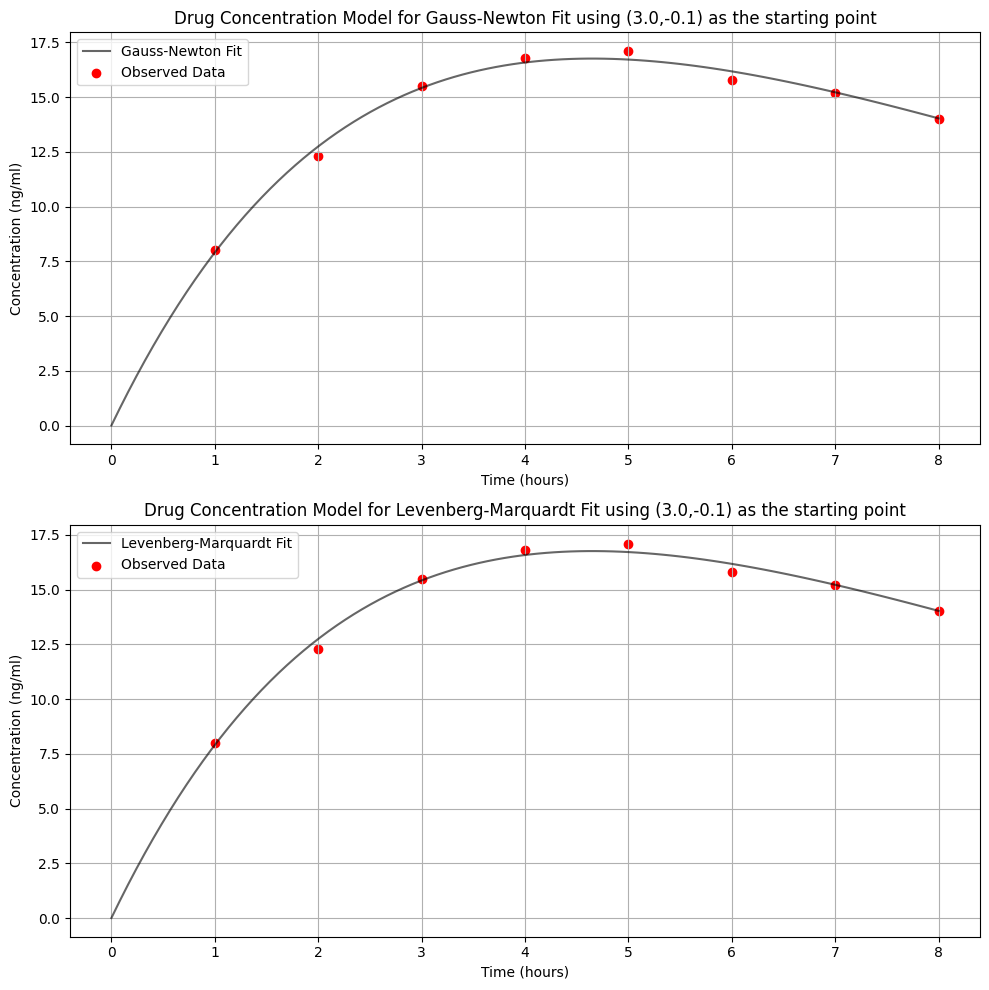

In [54]:
t = np.linspace(0, 8, 100)
plot_curvefit(t, func, [gn_result, lm_result], x0, ['Gauss-Newton Fit', 'Levenberg-Marquardt Fit'])

# (c)
Try to find a starting point such that Gauss-Newton does not converge, while Levenberg-Marquardt does.

In [59]:
# YOUR CODE HERE
x0 = np.array([3.0, -0.4])# Initial guess for which the Gauss-Neton does not converge the Levenberg-Marquardt does

gn_result, gn_iterations = gauss_newton(func, jacobian, hour, x0, concentration)
print(f" Gauss-Newton: c1 = {gn_result[0]:.2f}, c2 = {gn_result[1]:.2f}, Iterations = {gn_iterations}")

lm_result, lm_iterations = levenberg_marquardt(func, jacobian, hour, x0, concentration, mu=0.1)
print(f" Levenberg-Marquardt: c1 = {lm_result[0]:.2f}, c2 = {lm_result[1]:.2f}, Iterations = {lm_iterations}")

 Gauss-Newton: c1 = 0.56, c2 = -0.27, Iterations = 100
 Levenberg-Marquardt: c1 = 9.80, c2 = -0.22, Iterations = 26


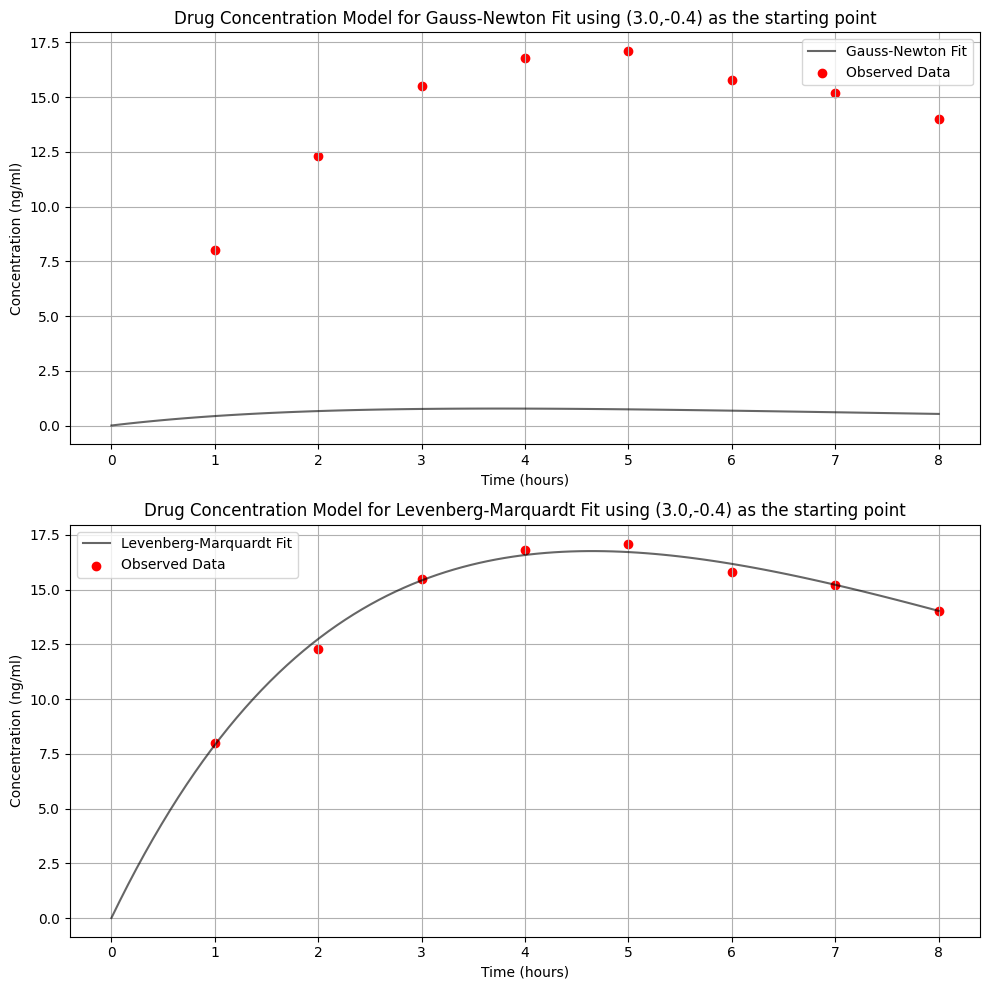

In [57]:
# Plot the curve fit
plot_curvefit(t, func, [gn_result, lm_result], x0, ['Gauss-Newton Fit', 'Levenberg-Marquardt Fit'])

# (d) 
So far for simplicity, we considered constant $\mu$. However
Levenberg-Marquardt is often applied adaptively with a varying $\mu$. 
A common strategy is to continue to decrease $\mu$ by a factor of 10 on each iteration step as long as the residual sum of squared errors is decreased by the step, and if the sum increases, to reject the step and increase $\mu$ by a factor of 10.

Implement an adaptive variant of Levenberg-Marquardt using such a strategy for choosing $\mu$. 

Compare the performance (iteration number) of the adaptive variant with Gauss-Newton and the previous, non-adaptive variant of Levenberg-Marquardt. Consider a starting point for which Gauss-Newton converged rapidly and a starting point for which Gauss-Newton did not converge, but non-adaptive Levenberg-Marquardt did. Give your answer in a table for clarity, also indicating the starting point and if relevant other parameters.

In [60]:
def adaptive_levenberg_marquardt(func, jacobian, t, x0, y, tol=1e-6, maxIter=100, mu=0.01):
    x = x0              # Initial guess
    prev_sse = np.inf   # Previous sum of squared errors 

    for iter in range(maxIter):
        r = y - func(t, x)  # Residual
        J = jacobian(t, x)  # Jacobian of the function

        sse = np.sum(r**2)  # Sum of squared errors

        gradient = J.T @ r  # Gradient of the function
        H = J.T @ J         # Hessian of the function, A^t*A

        I = np.eye(H.shape[0])
        delta_x = np.linalg.solve(H + mu * I, gradient)

        x_new = x + delta_x # Update x

        # Adaptive mu: If the new sum of squared errors is 
        # less than the previous sum of squared errors, decrease mu
        if sse < prev_sse:
            mu /= 10  
            prev_sse = sse   # Update the previous sum of squared errors
            x = x_new        # Update x
        else:
            mu *= 10         # Otherwise, increase mu
        
        # Check if delta is small enough, if so return the solution
        if np.linalg.norm(delta_x) < tol:
            return x, iter + 1

    return x, maxIter

In [109]:
x0 = np.array([3.0, -0.1])

alm_result, alm_iterations = adaptive_levenberg_marquardt(func, jacobian, hour, x0, concentration, mu=0.1)
print(f" Adaptive Levenberg-Marquardt: c1 = {alm_result[0]:.2f}, c2 = {alm_result[1]:.2f}, Iterations = {alm_iterations}")

lm_result, lm_iterations = levenberg_marquardt(func, jacobian, hour, x0, concentration, mu=0.1)
print(f" Levenberg-Marquardt: c1 = {lm_result[0]:.2f}, c2 = {lm_result[1]:.2f}, Iterations = {lm_iterations}")

gn_result, gn_iterations = gauss_newton(func, jacobian, hour, x0, concentration)
print(f" Gauss-Newton: c1 = {gn_result[0]:.2f}, c2 = {gn_result[1]:.2f}, Iterations = {gn_iterations}")

 Adaptive Levenberg-Marquardt: c1 = 9.80, c2 = -0.22, Iterations = 7
 Levenberg-Marquardt: c1 = 9.80, c2 = -0.22, Iterations = 10
 Gauss-Newton: c1 = 9.80, c2 = -0.22, Iterations = 7


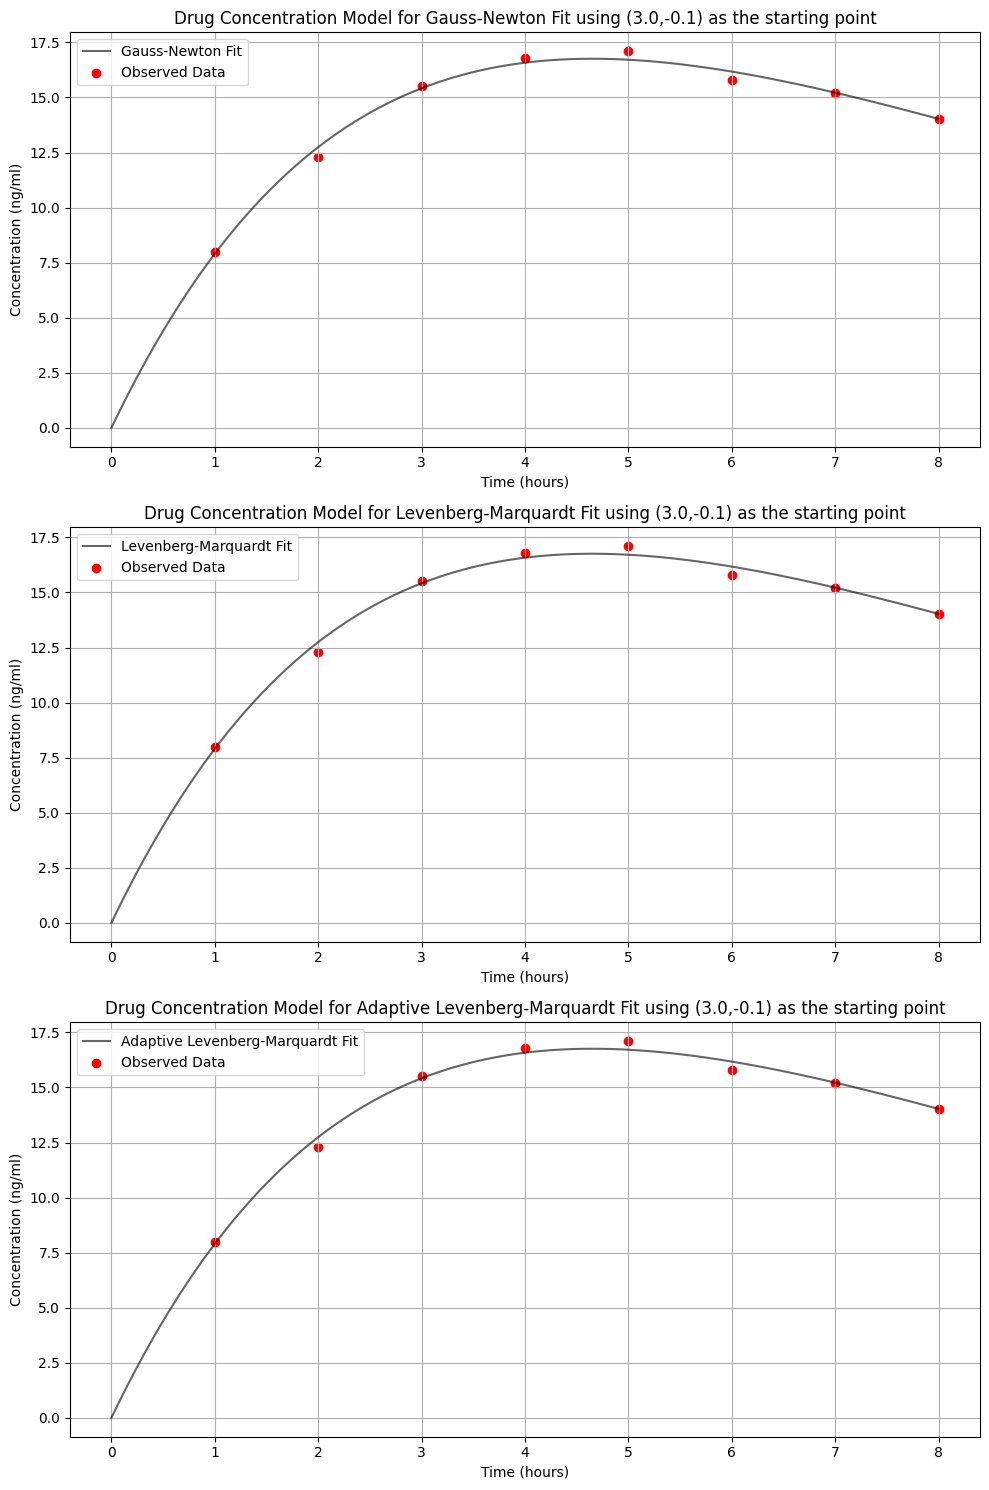

In [107]:
# Plot the curve fits
plot_curvefit(t, func, [gn_result, lm_result, alm_result], x0, 
              ['Gauss-Newton Fit', 'Levenberg-Marquardt Fit', 'Adaptive Levenberg-Marquardt Fit'])

In [110]:
# Initial guesses
x_values = np.linspace(0, 5, 1000)
y_values = np.linspace(-1, 2, 1000)

for x in x_values:
    for y in y_values:
        x0 = np.array([x, y])
        try:
            alm_result, alm_iterations = adaptive_levenberg_marquardt(func, jacobian, hour, x0, concentration, mu=0.1)
            # print(f"x0 = {x0}, Adaptive Levenberg-Marquardt: c1 = {alm_result[0]:.2f}, c2 = {alm_result[1]:.2f}, Iterations = {alm_iterations}")
        except np.linalg.LinAlgError as e:
            if 'Singular matrix' in str(e):
                # print("Error for Adaptive Levenberg-Marquardt, x0 = ", x0, "Error: Singular matrix")
                print(end="")
            continue
        except RuntimeWarning:
                # print("Error for Adaptive Levenberg-Marquardt, x0 = ", x0, "Error: Overflow")
            print(end="")
            continue

        try:
            gn_result, gn_iterations = gauss_newton(func, jacobian, hour, x0, concentration)
            # print(f"x0 = {x0}, Gauss-Newton: c1 = {gn_result[0]:.2f}, c2 = {gn_result[1]:.2f}, Iterations = {gn_iterations}")
        except np.linalg.LinAlgError as e:
            if 'Singular matrix' in str(e):
                # print("Error for Gauss-Newton, x0 = ", x0, "Error: Singular matrix")
                print(end="")
            continue
        except RuntimeWarning:
            print(end="")
            continue

        if round(alm_result[0], 2) == 9.80 and round(alm_result[1], 2) == -0.22:
            if round(gn_result[0], 2) != 9.80 and round(gn_result[1], 2) != -0.22:
                print(f"Solution: {x0}")
                break

/var/folders/t_/qrs810y11rl2d5xqzdqstglh0000gn/T/ipykernel_26297/1009906665.py:3: RuntimeWarning: overflow encountered in exp
  return c[0] * t * np.exp(c[1] * t)
/var/folders/t_/qrs810y11rl2d5xqzdqstglh0000gn/T/ipykernel_26297/1009906665.py:8: RuntimeWarning: overflow encountered in exp
  J[:, 0] = t * np.exp(c[1] * t)
/var/folders/t_/qrs810y11rl2d5xqzdqstglh0000gn/T/ipykernel_26297/1009906665.py:9: RuntimeWarning: overflow encountered in exp
  J[:, 1] = c[0] * t**2 * np.exp(c[1] * t)
/var/folders/t_/qrs810y11rl2d5xqzdqstglh0000gn/T/ipykernel_26297/1807358346.py:8: RuntimeWarning: overflow encountered in matmul
  gradient = J.T @ r  # Gradient of the function
/var/folders/t_/qrs810y11rl2d5xqzdqstglh0000gn/T/ipykernel_26297/1807358346.py:9: RuntimeWarning: overflow encountered in matmul
  H = J.T @ J         # Hessian of the function, A^t*A
/var/folders/t_/qrs810y11rl2d5xqzdqstglh0000gn/T/ipykernel_26297/1009906665.py:3: RuntimeWarning: overflow encountered in multiply
  return c[0] * 

Solution: [ 0.00500501 -0.21021021]
Solution: [ 0.01001001 -0.21021021]


/var/folders/t_/qrs810y11rl2d5xqzdqstglh0000gn/T/ipykernel_26297/1009906665.py:8: RuntimeWarning: overflow encountered in multiply
  J[:, 0] = t * np.exp(c[1] * t)


Solution: [ 0.01501502 -0.20720721]


/var/folders/t_/qrs810y11rl2d5xqzdqstglh0000gn/T/ipykernel_26297/1473348013.py:9: RuntimeWarning: overflow encountered in square
  sse = np.sum(r**2)  # Sum of squared errors
/var/folders/t_/qrs810y11rl2d5xqzdqstglh0000gn/T/ipykernel_26297/1473348013.py:11: RuntimeWarning: overflow encountered in matmul
  gradient = J.T @ r  # Gradient of the function
/var/folders/t_/qrs810y11rl2d5xqzdqstglh0000gn/T/ipykernel_26297/1473348013.py:12: RuntimeWarning: overflow encountered in matmul
  H = J.T @ J         # Hessian of the function, A^t*A


KeyboardInterrupt: 

In [111]:
# x0 = np.array([0.01001001, -0.21021021])
x0 = np.array([0.01, -0.21])

alm_result, alm_iterations = adaptive_levenberg_marquardt(func, jacobian, hour, x0, concentration, mu=0.1)
print(f" Adaptive Levenberg-Marquardt: c1 = {alm_result[0]:.2f}, c2 = {alm_result[1]:.2f}, Iterations = {alm_iterations}")

gn_result, gn_iterations = gauss_newton(func, jacobian, hour, x0, concentration)
print(f" Gauss-Newton: c1 = {gn_result[0]:.2f}, c2 = {gn_result[1]:.2f}, Iterations = {gn_iterations}")

 Adaptive Levenberg-Marquardt: c1 = 9.80, c2 = -0.22, Iterations = 7
 Gauss-Newton: c1 = nan, c2 = nan, Iterations = 100


/var/folders/t_/qrs810y11rl2d5xqzdqstglh0000gn/T/ipykernel_26297/1009906665.py:3: RuntimeWarning: overflow encountered in exp
  return c[0] * t * np.exp(c[1] * t)
/var/folders/t_/qrs810y11rl2d5xqzdqstglh0000gn/T/ipykernel_26297/1009906665.py:8: RuntimeWarning: overflow encountered in exp
  J[:, 0] = t * np.exp(c[1] * t)
/var/folders/t_/qrs810y11rl2d5xqzdqstglh0000gn/T/ipykernel_26297/1009906665.py:9: RuntimeWarning: overflow encountered in exp
  J[:, 1] = c[0] * t**2 * np.exp(c[1] * t)


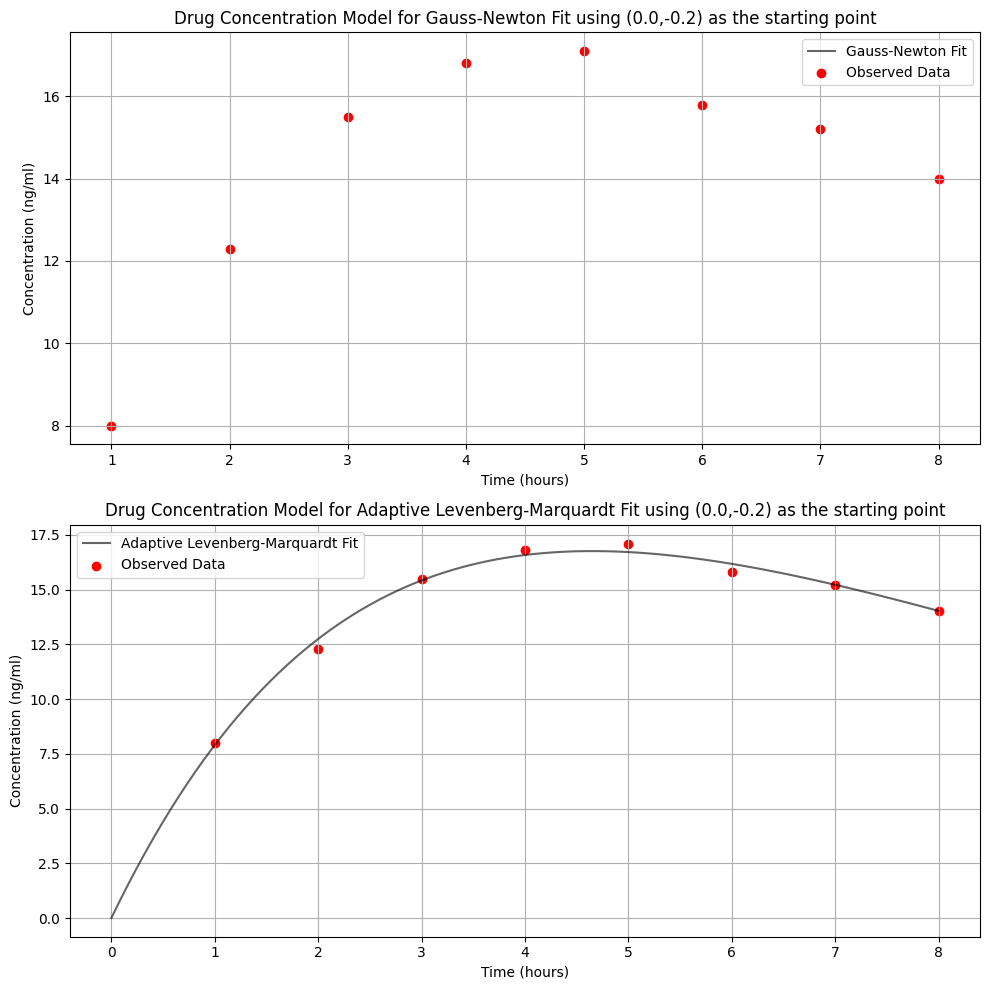

In [112]:
# Plot the curve fits
plot_curvefit(t, func, [gn_result, alm_result], x0, ['Gauss-Newton Fit', 'Adaptive Levenberg-Marquardt Fit'])

## Test to see for which initial points ALM converges but GN doesn't

In [26]:
# Generate the heatmap
def plot_convergence_heatmap(optimize_func, func, jacobian, t, y, x_range, y_range, tol, max_iter, target):
    c1_values = np.linspace(x_range[0], x_range[1], 100)
    c2_values = np.linspace(y_range[0], y_range[1], 100)
    grid = np.meshgrid(c1_values, c2_values)
    
    results = np.zeros(grid[0].shape)
    target_c1, target_c2 = target

    for i in range(grid[0].shape[0]):
        for j in range(grid[1].shape[1]):
            c0 = [grid[0][i, j], grid[1][i, j]]
            try:
                c_opt, _ = optimize_func(func, jacobian, t, c0, y, tol=tol, maxIter=max_iter)
                if np.linalg.norm(np.array(c_opt) - np.array(target)) < tol:
                    results[i, j] = 1  # Converged
                else:
                    results[i, j] = 0  # Did not converge
            except:
                results[i, j] = -1  # Diverged or error

    # Plot heatmap
    plt.figure(figsize=(8, 6))
    plt.imshow(results, extent=(x_range[0], x_range[1], y_range[0], y_range[1]), origin='lower', cmap='coolwarm', alpha=0.8)
    plt.colorbar(label="Convergence (1 = Converged, 0 = Did not converge, -1 = Diverged)")
    plt.xlabel("Initial c1")
    plt.ylabel("Initial c2")
    plt.title(f"Convergence Heatmap for {optimize_func.__name__}")
    plt.grid()
    plt.show()

# Example usage
# Time data and target y values
t = np.linspace(0, 8, 50)
true_c = [9.8, -0.22]
y = func(t, true_c)

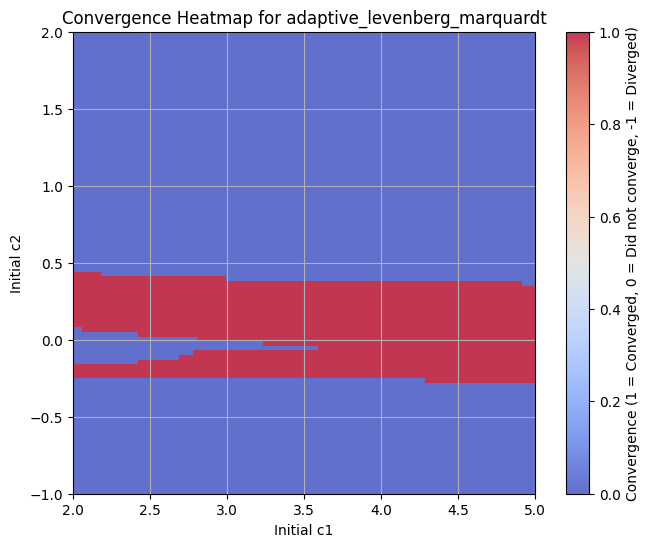

In [23]:
# Plot heatmap
# Adaptive Levenberg-Marquardt
plot_convergence_heatmap(
    adaptive_levenberg_marquardt,
    func, jacobian, t, y,
    x_range=(2, 5),  # Range for c1
    y_range=(-1, 2),  # Range for c2
    tol=1e-6,
    max_iter=100,
    target=true_c
)

/var/folders/t_/qrs810y11rl2d5xqzdqstglh0000gn/T/ipykernel_26297/539757197.py:8: RuntimeWarning: overflow encountered in matmul
  gradient = J.T @ r     # Gradient of the function
/var/folders/t_/qrs810y11rl2d5xqzdqstglh0000gn/T/ipykernel_26297/539757197.py:9: RuntimeWarning: overflow encountered in matmul
  H = J.T @ J            # Hessian of the function, A^t*A


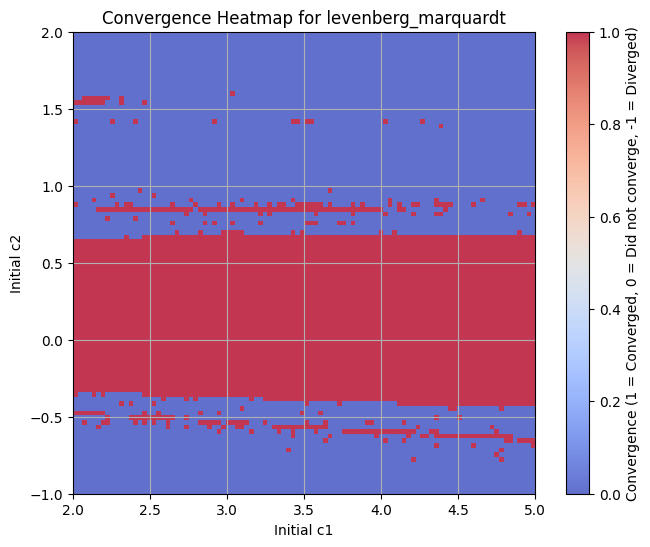

In [25]:
# Levenberg-Marquardt
plot_convergence_heatmap(
    levenberg_marquardt,
    func, jacobian, t, y,
    x_range=(2, 5),  # Range for c1
    y_range=(-1, 2),  # Range for c2
    tol=1e-6,
    max_iter=100,
    target=true_c
)

/var/folders/t_/qrs810y11rl2d5xqzdqstglh0000gn/T/ipykernel_26297/1009906665.py:3: RuntimeWarning: overflow encountered in exp
  return c[0] * t * np.exp(c[1] * t)
/var/folders/t_/qrs810y11rl2d5xqzdqstglh0000gn/T/ipykernel_26297/1009906665.py:8: RuntimeWarning: overflow encountered in exp
  J[:, 0] = t * np.exp(c[1] * t)
/var/folders/t_/qrs810y11rl2d5xqzdqstglh0000gn/T/ipykernel_26297/1009906665.py:9: RuntimeWarning: overflow encountered in exp
  J[:, 1] = c[0] * t**2 * np.exp(c[1] * t)
/var/folders/t_/qrs810y11rl2d5xqzdqstglh0000gn/T/ipykernel_26297/158291482.py:8: RuntimeWarning: overflow encountered in matmul
  gradient = J.T @ r  # Gradient of the function
/var/folders/t_/qrs810y11rl2d5xqzdqstglh0000gn/T/ipykernel_26297/158291482.py:9: RuntimeWarning: overflow encountered in matmul
  H = J.T @ J + 1e-8 * np.eye(J.shape[1])  # Hessian with regularization term
/var/folders/t_/qrs810y11rl2d5xqzdqstglh0000gn/T/ipykernel_26297/1009906665.py:3: RuntimeWarning: overflow encountered in mult

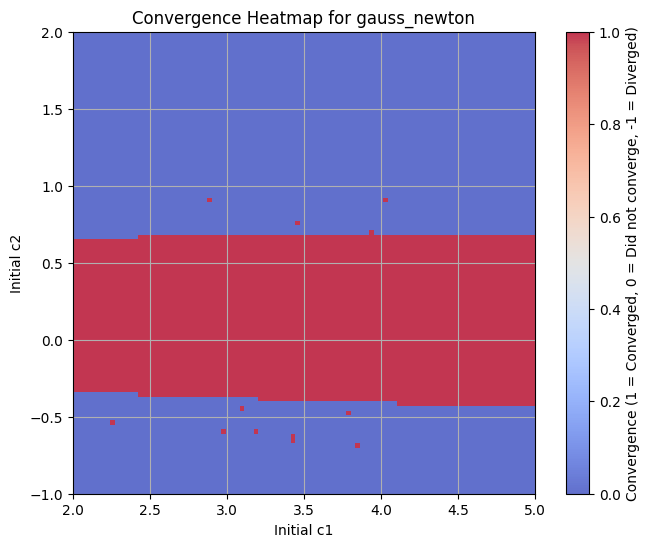

In [39]:
# Gauss-Newton
plot_convergence_heatmap(
    gauss_newton,
    func, jacobian, t, y,
    x_range=(2, 5),  # Range for c1
    y_range=(-1, 2),  # Range for c2
    tol=1e-6,
    max_iter=100,
    target=true_c
)